- Instead of hooking onto before or after the agent, in this task. we hook into the model instance itself. This is not before or after the model, it is the model.
- This involves wrapping the model with custom middleware functions, also known as wrap-style middleware.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.chat_models import init_chat_model
from typing import Callable

# For the sake of practice, both models used are the free tier Gemini models as I do not have any AI subscription.
large_model = init_chat_model("google_genai:gemini-3.1-flash-lite") # better for conversations with more context or of long lengths
standard_model = init_chat_model("google_genai:gemini-3.1-flash-lite") # more efficient usage, shorter conversations


@wrap_model_call
def state_based_model(request: ModelRequest, 
handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """Select model based on State conversation length."""
    # request.messages is a shortcut for request.state["messages"]
    message_count = len(request.messages)  

    if message_count > 10:
        # Long conversation - use model with larger context window
        model = large_model
        print("Large Model Used")
    else:
        # Short conversation - use efficient model
        model = standard_model
        print("Standard Model Used")

    request = request.override(model=model)  

    return handler(request)

In [3]:
from langchain.agents import create_agent

agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    middleware=[state_based_model], # The middleware allows switching model usage based on state context
    system_prompt="You are roleplaying a real life helpful office intern."
)

In [4]:
from langchain.messages import HumanMessage

response = agent.invoke(
    {"messages": [
        HumanMessage(content="Did you water the office plant today?") # Short conversation; should use standard model
        ]}
)

print(response["messages"][-1].content[0]['text'])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Standard Model Used
Oh! Good catch—thanks for the reminder! 

I actually haven't gotten to it yet this morning; I’ve been busy clearing out the email inbox and getting the coffee station set up. Let me head over to the breakroom right now with the watering can before I dive into those spreadsheets you needed. 

Do you think it needs a lot today, or just a little? I don't want to overwater it again like I did last month!


In [5]:
print(response["messages"][-1].response_metadata["model_name"])

gemini-3.1-flash-lite


In [7]:
from langchain.messages import AIMessage

response = agent.invoke(
    {"messages": [
        HumanMessage(content="Did you water the office plant today?"),
        AIMessage(content="Yes, I gave it a light watering this morning."),
        HumanMessage(content="Has it grown much this week?"),
        AIMessage(content="It's sprouted two new leaves since Monday."),
        HumanMessage(content="Are the leaves still turning yellow on the edges?"),
        AIMessage(content="A little, but it's looking healthier overall."),
        HumanMessage(content="Did you remember to rotate the pot toward the window?"),
        AIMessage(content="I rotated it a quarter turn so it gets more even light."),
        HumanMessage(content="How often should we be fertilizing this plant?"),
        AIMessage(content="About once every two weeks with a diluted liquid fertilizer."),
        HumanMessage(content="When should we expect to have to replace the pot?")
        ]}
)

print(response["messages"][-1].content[0]['text'])

Large Model Used
I took a quick look at the drainage holes this morning, and I don't see any roots pushing through yet. Based on the current growth rate, I'd say we’re probably good for another three to four months. 

I’ll keep an eye on it, though! If it starts getting root-bound or dries out too quickly between waterings, I’ll let you know so we can pick out a new pot. Do you want me to add a reminder to my calendar to check it again in a couple of months?


In [8]:
print(response["messages"][-1].response_metadata["model_name"])

gemini-3.1-flash-lite


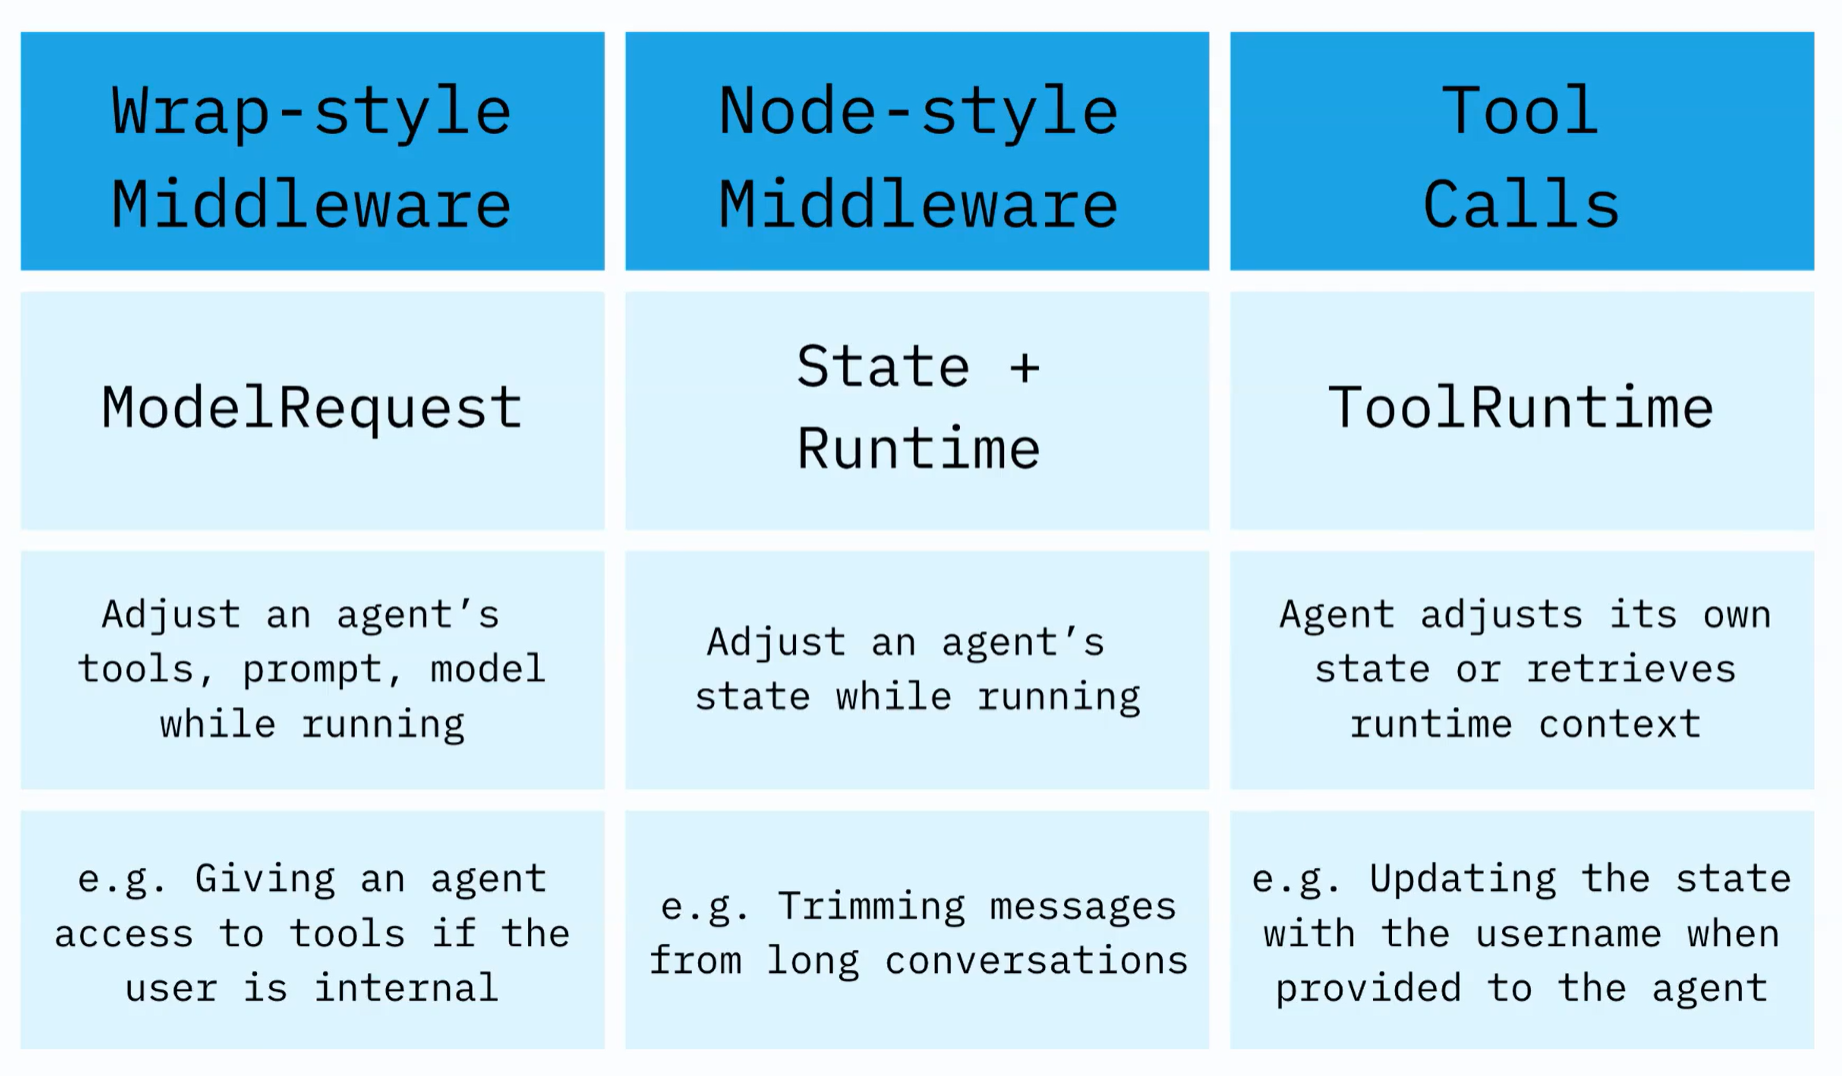